## Lock in the real-world graph
In this notebook, we set up a basic simulation where two vessels cross a lock complex in a real-world graph. We take the eastern lock chamber of the Volkerak sluices (rightern most lock chamber in the picture below).

![OpenTNSim-Volkeraksluizen](figures/0206_Volkeraksluizen.png)


In [23]:
# package(s) used for creating and geo-locating the graph
import networkx as nx
import pyproj
from shapely.geometry import Point, LineString, Polygon
from shapely.ops import transform

# package to navigate through files and folders
import os

# package(s) related to the simulation (creating the vessel, running the simulation)
import datetime
import simpy
import opentnsim
from opentnsim.core.utils import create_object
from opentnsim.graph import mixins as graph_module
from opentnsim.core.logutils import logbook2eventtable
from opentnsim.core import Identifiable, Movable, VesselProperties, ExtraMetadata
from opentnsim.core.visualizations import generate_vessel_gantt_chart
import opentnsim.fis as fis
from opentnsim.graph.calculations import (transform_geometry, calculate_bounding_rectangle, flip_coordinates, split_edge_based_on_geometry_along_edge,
                                          calculate_length_of_splitted_edge_geometries, calculate_the_distances_from_doors_to_edge_nodes, 
                                          calculate_object_dimensions_and_alignment, split_edge_based_on_point_along_edge,
                                          merge_two_consecutive_edges_based_on_shared_node, transform_geometry)
from opentnsim.graph.mixins import HasMultiDiGraph
from opentnsim.graph.utils import find_edges_in_a_polygon, find_nodes_in_a_polygon, get_trajectory, create_transformer
from opentnsim.graph.visualizations import create_real_world_graph
from opentnsim.output import HasOutput

# import of modules important for locking
from opentnsim.lock import IsLockChamber, IsLockWaitingArea, IsLockComplex, LockComplexTraversable
from opentnsim.lock.visualizations import spatially_visualize_lock_complex

# package(s) needed for inspecting the output
import pandas as pd
import matplotlib.pyplot as plt

# package(s) needed for inspecting the output
import pandas as pd
import geopandas as gpd
import numpy as np

# package needed to download the lock geometry
import requests

# package to assess the progress of functions
from tqdm import tqdm

# plot libraries
import folium

print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 1.3.4


In [2]:
%load_ext autoreload
%autoreload 2

#### 0. Create environment

In [3]:
# start simpy environment
simulation_start = datetime.datetime(2025, 1, 1, 0, 0, 0)
env = simpy.Environment(initial_time=simulation_start.timestamp())
env.epoch = simulation_start

#### 1. Create graph
Next we create a network (a graph) along which the vessel can move. For this case we use the Fairway Information System graph, and make the vessels sail from one side of the lock to another side.

In [4]:
# load the processed version from the Fairway Information System graph provided by Rijkswaterstaat
FG = fis.load_network(version="0.3")

The edges in the FIS-graph (FG) have geometry attributes in the WGS84-reference system. Distances between points in this reference system are calculated in degrees, but edges in the FG have a length_m attribute with their length in meters. Later, we will do some operations in which we need to accurately convert units from WGS84 (degrees) into meters. For this, we use the Amersfoort / RD New reference system, which locally in the Netherlands gives the most accurate results. As the original length_m deviates from the distances measured in the RD-system, we have to update the length_m paramters

In [5]:
transformer = create_transformer(crs_out='EPSG:28992') #From WGS84 to Amersfoort / RD New reference system
for edge in tqdm(FG.edges):
    geometry = get_trajectory(FG,edge[0],edge[1])[0]
    if geometry is not None:
        geometry_m = transform_geometry(geometry, transformer=transformer) 
        FG.edges[edge]['geometry'] = geometry
        FG.edges[edge]['length_m'] = geometry_m.length

100%|██████████████████████████████████████████████████████████████████████████| 16164/16164 [00:03<00:00, 4541.66it/s]


We add the graph to the environment

In [6]:
# add graph to environment
env.graph = FG

#### 1+ Infrastructure
We have to schematize our sluice of the Volkerak. For this, we have to download the geometry of the sluice. For this, we use [openstreetmap](https://www.openstreetmap.org/#map=17/51.689765/4.410560) and create an API.

In [7]:
# Use faster server
url = "https://overpass.kumi.systems/api/interpreter"

# Berlin bounding box (faster than area lookup)
query = """
[out:json][timeout:180];
nwr["lock_name"~"Oostkolk"](51.68005,4.38958,51.70062,4.42933);
out geom;
"""

response = requests.get(url, params={'data': query})
data = response.json()

# Convert to DataFrame
elements = data["elements"]

df = pd.json_normalize(elements)

# Create geometry column
df['geometry'] = df.apply(lambda row: Polygon((p["lon"], p["lat"]) for p in row.geometry), axis=1)

# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326")

# We get two objects that are similar
gdf.head()

,type,id,nodes,geometry,bounds.minlat,bounds.minlon,bounds.maxlat,bounds.maxlon,tags.CEMT,tags.boat,...,tags.maxwidth,tags.name,tags.natural,tags.phone,tags.url,tags.vhf,tags.water,tags.wikidata,tags.wikipedia,tags.waterway
0,way,56198966,"[4515246328, 8536258682, 8536258681, 451524632...","POLYGON ((4.40799 51.68904, 4.40801 51.68903, ...",51.688860,4.407993,51.691111,4.412082,VIb,yes,...,24.1,Volkeraksluizen,water,+31 88 797 4990,https://youtu.be/VHbaJfyRVzU,7;25;64,lock,Q1886412,nl:Volkeraksluizen,NaN
1,way,251906187,"[4515246327, 2580607082, 4297997740, 451524632...","POLYGON ((4.40807 51.68892, 4.40823 51.68901, ...",51.688925,4.408070,51.691053,4.411981,VIb,yes,...,24.1,Volkeraksluizen,NaN,+31 88 797 4990,NaN,7;25;64,NaN,Q1886412,nl:Volkeraksluizen,canal


We store the geometry of the first instance to be used as the geometry for our lock

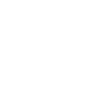

In [8]:
lock_geometry = gdf.geometry.iloc[0]
lock_geometry

We also have to set the depth of the lock

In [9]:
lock_depth = 6.2 #information based on RWS

##### Lock chamber
With the above information, we try to add a Lock Chamber to the environment:

In [10]:
try:
    lock_chamber = IsLockChamber(env=env,
                                 name='Oostkolk',
                                 geometry = lock_geometry,
                                 lock_depth = lock_depth,
                                 crs_m='EPSG:4087') #Amersfoort / RD New reference system
except:
    print('The FIS-graph is not fit to model the lock chamber, as the lock geometry covers multiple edges. '+
          'The locking-module only supports locks on single edges, without nodes within the geometry. We need to modify the FIS-graph.')

The FIS-graph is not fit to model the lock chamber, as the lock geometry covers multiple edges. The locking-module only supports locks on single edges, without nodes within the geometry. We need to modify the FIS-graph.


#### 1. Create graph (Second try)

There are nodes within the lock geometry, which we have to find, merge their edges and remove.

In [11]:
nodes_within_the_lock_chamber = find_nodes_in_a_polygon(FG, lock_geometry)
nodes_within_the_lock_chamber

['L42863_A', 'L42863_B']

We can remove the nodes and merge the edges between them (using a predefined function)

In [12]:
for node in nodes_within_the_lock_chamber:
    FG = merge_two_consecutive_edges_based_on_shared_node(FG,node)

Check if we now have a single lock edge

In [13]:
lock_node_A, lock_node_B = find_edges_in_a_polygon(FG,lock_geometry)[0]
lock_edge = (lock_node_A, lock_node_B)
lock_edge

('8862498', 'B34113_A')

In [14]:
env.graph = FG

#### 1+ Add infrastructure (Second try)

In [15]:
lock_chamber = IsLockChamber(env=env,
                             name='Oostkolk',
                             geometry = lock_geometry,
                             lock_depth = lock_depth,
                             crs_m='EPSG:28992') #Amersfoort / RD New reference system

In [16]:
# The minimum required input for a lock complex are waiting areas at both sides of the lock
waiting_area_A = IsLockWaitingArea(env=env,
                                   name = 'Waiting area A',
                                   lock_chamber = lock_chamber,
                                   distance_from_lock_gate_A = 260)

In [17]:
waiting_area_B = IsLockWaitingArea(env=env,
                                   name = 'Waiting area B',
                                   lock_chamber = lock_chamber,
                                   distance_from_lock_gate_B = 370)

In [33]:
waiting_area_A.edge, waiting_area_B.edge

(('8862498', '8860743'), ('8862498', 'B34113_A'))

In [18]:
node_A = waiting_area_A.edge[0]
node_B = waiting_area_B.edge[0]

lock_complex = IsLockComplex(lock_chambers = [lock_chamber],
                             waiting_areas = [waiting_area_A, waiting_area_B],
                             registration_nodes = [node_A, node_B],
                             env=env,
                             name = 'Lock complex',)

We can visualize the lock complex

In [22]:
spatially_visualize_lock_complex(lock_complex)

#### 2. Create agents

In [24]:
# make your preferred Vessel class out of available mix-ins.
Vessel = create_object(
    "Vessel", 
    (
        LockComplexTraversable,     # allows to interact with a lock
        Identifiable,               # allows to give the object a name and a random ID,
        Movable,                    # allows the object to move, with a fixed speed, while logging this activity
        VesselProperties,           # allows vessel to have dimensions, namely a length (L), width (B), and draught (T)
        ExtraMetadata,              # allow additional information, such as an arrival time (required for passing a lock)
        HasMultiDiGraph,            # allow to operate on a graph that can include parallel edges from and to the same nodes
        HasOutput,                  # allow additional output to be stored
    ), 
)

In [25]:
def mission(env, vessel):
    """
    Method that defines the mission of the vessel.
    
    In this case: 
        keep moving along the path until its end point is reached
    """
    while True:
        yield from vessel.move()
        
        if vessel.geometry == nx.get_node_attributes(env.graph, "geometry")[vessel.route[-1]]:
            break

In [26]:
# create vessels from dict 
data_vessel_1 = {
    "env": env,                                          # needed for simpy simulation
    "name": "Vessel 1",                                  # required by Identifiable
    "geometry": env.graph.nodes[node_A]['geometry'],     # required by Locatable
    "route": nx.dijkstra_path(env.graph, node_A, node_B),# required by Routeable
    "v": 4,                                              # required by Movable, 4 m/s to check if the distance is covered in the expected time
    "L": 100,                                            # required by VesselProperties, interacts with the lock capacity
    "B": 20,                                             # required by VesselProperties
    "T": 5,                                              # required by VesselProperties
    "type": 'tanker',                                    # required by VesselProperties
    "arrival_time": pd.Timestamp('2025-01-01 00:00:00')  # required by PassesLockComplex
}  
vessel_1 = Vessel(**data_vessel_1)
vessel_1.name = 'Vessel 1'

data_vessel_2 = {
    "env": env,                                          # needed for simpy simulation
    "name": "Vessel 2",                                  # required by Identifiable
    "geometry": env.graph.nodes[node_B]['geometry'],     # required by Locatable
    "route": nx.dijkstra_path(env.graph, node_B, node_A),# required by Routeable
    "v": 4,                                              # required by Movable, 4 m/s to check if the distance is covered in the expected time
    "L": 100,                                            # required by VesselProperties, interacts with the lock capacity
    "B": 20,                                             # required by VesselProperties
    "T": 5,                                              # required by VesselProperties
    "type": 'tanker',                                    # required by VesselProperties
    "arrival_time": pd.Timestamp('2025-01-01 00:05:00')  # required by PassesLockComplex
}  
vessel_2 = Vessel(**data_vessel_2)
vessel_2.name = 'Vessel 2'

# start the simulation
env.process(mission(env, vessel_1))
env.process(mission(env, vessel_2))

<Process(mission) object at 0x188dc1fb0a0>

#### 3. Run simulation

In [27]:
env.run()

#### 4. Inspect output

In [32]:
# We can plot the time-distance diagram
fig = lock_chamber.plot(xlimmin = -1500, 
                        xlimmax = 1500,
                        method = 'Matplotlib')

['8862498', '8862498']
None


AttributeError: 'NoneType' object has no attribute 'is_empty'

In [ ]:
# load the logbook data into a dataframe
df = pd.DataFrame.from_dict(vessel_1.logbook)

print("'{}' logbook data:".format(vessel_1.name))  
print('')

display(df)

In [ ]:
# load the logbook data into a dataframe
df = pd.DataFrame.from_dict(vessel_2.logbook)

print("'{}' logbook data:".format(vessel_2.name))  
print('')

display(df)

In [ ]:
# load the logbook data into a dataframe
df = pd.DataFrame.from_dict(lock_chamber.logbook)

print("'{}' logbook data:".format(lock_chamber.name))  
print('')

display(df)